# Common 102-string / 160-string test events

Build a one-row-per-event master dataframe for events shared by the 102-string and 160-string test sets. The three router files are checked for identical event coverage within each detector configuration, and truth-level `final_weight` is joined using the full physics event key.

In [1]:
import os
import sys
from pathlib import Path

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np

# Recover cleanly if an earlier interrupted import left pandas half-loaded.
_loaded_pandas = sys.modules.get("pandas")
if _loaded_pandas is not None and not hasattr(_loaded_pandas, "core"):
    for _module_name in list(sys.modules):
        if _module_name == "pandas" or _module_name.startswith("pandas."):
            del sys.modules[_module_name]
import pandas as pd
from IPython.display import display


results_dir = Path(
    "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC"
)
weight_dir = Path(
    "/project/def-nahee/kbas/Graphnet-Applications/Metadata/"
    "DatasetStatistics/TruthLevelStatistics"
)

router_directories = {
    "router1": "category1_isMuonCC",
    "router2": "category2_tauCC_others_muonCC",
    "router3": "category_3_contains_muon",
}
detector_strings = ("102", "160")
id_columns = ["pid", "is_CC", "RunID", "SubrunID", "EventID", "SubEventID"]

inference_frames = {}
for detector in detector_strings:
    inference_frames[detector] = {}
    for router_name, router_directory in router_directories.items():
        prediction_file = (
            results_dir
            / f"{detector}_string_emax1e6"
            / "inference"
            / router_directory
            / "baseline"
            / "inference"
            / "inference_predictions.csv"
        )
        frame = pd.read_csv(prediction_file)
        frame[id_columns] = frame[id_columns].astype(np.int64)
        if frame.duplicated(id_columns).any():
            raise ValueError(f"Duplicate physics event keys in {prediction_file}")
        inference_frames[detector][router_name] = frame

weight_files = [weight_dir / f"{sample}.csv" for sample in ["Electron", "Muon", "Tau", "NC"]]
weight_df = pd.concat(
    [pd.read_csv(path, usecols=id_columns + ["final_weight"]) for path in weight_files],
    ignore_index=True,
)
weight_df[id_columns] = weight_df[id_columns].astype(np.int64)
if weight_df.duplicated(id_columns).any():
    raise ValueError("Truth-level weight files contain duplicate physics event keys")

## Event coverage by interaction category

In [2]:
def event_index(frame):
    return pd.MultiIndex.from_frame(frame[id_columns])


reference_indices = {}
for detector in detector_strings:
    router_indices = {
        router_name: event_index(frame)
        for router_name, frame in inference_frames[detector].items()
    }
    reference_index = router_indices["router1"]
    for router_name, index in router_indices.items():
        if not index.equals(reference_index):
            if set(index) != set(reference_index):
                raise ValueError(
                    f"{detector}-string {router_name} does not use the same test events"
                )
    reference_indices[detector] = reference_index

events_102 = set(reference_indices["102"])
events_160 = set(reference_indices["160"])
common_events = events_102 & events_160
only_102_events = events_102 - events_160
only_160_events = events_160 - events_102

event_categories = [
    ("Electron CC", 12, 1),
    ("Electron NC", 12, 0),
    ("Tau CC", 16, 1),
    ("Muon CC", 14, 1),
]
coverage_rows = []
for category_label, abs_pid, is_cc in event_categories:
    count_category = lambda events: sum(
        (abs(event[0]) == abs_pid) and (event[1] == is_cc)
        for event in events
    )
    coverage_rows.append(
        {
            "category": category_label,
            "common": count_category(common_events),
            "only_102": count_category(only_102_events),
            "only_160": count_category(only_160_events),
            "total_102": count_category(events_102),
            "total_160": count_category(events_160),
        }
    )
coverage_rows.append(
    {
        "category": "All events",
        "common": len(common_events),
        "only_102": len(only_102_events),
        "only_160": len(only_160_events),
        "total_102": len(events_102),
        "total_160": len(events_160),
    }
)
coverage_report = pd.DataFrame(coverage_rows).set_index("category")
display(coverage_report)
print("Router event-set check passed for both detector configurations.")

,common,only_102,only_160,total_102,total_160
category,,,,,
Electron CC,6359,0,2002,6359,8361
Electron NC,6541,0,2599,6541,9140
Tau CC,9553,0,2981,9553,12534
Muon CC,20536,0,2864,20536,23400
All events,42989,0,10446,42989,53435


Router event-set check passed for both detector configurations.


## Master dataframe for common events

In [3]:
common_index = pd.MultiIndex.from_tuples(common_events, names=id_columns)
reference_102 = inference_frames["102"]["router1"].set_index(id_columns)

truth_columns = [
    "position_x", "position_y", "position_z", "totalEnergy",
    "zenith", "azimuth", "finalStateX", "finalStateY",
    "finalType1", "finalType2", "initialType", "totalColumnDepth",
    "impactParameter", "fully_contained", "starting_track",
    "stopping_track", "through_going", "missed_track",
    "category1_isMuonCC", "category2_tauCC_others_muonCC",
    "category_3_contains_muon", "true_energy", "true_log10_energy",
    "true_zenith_radian", "true_zenith_degree",
    "true_azimuth_radian", "true_azimuth_degree",
]
master_df = reference_102.loc[common_index, truth_columns].reset_index()
master_df = master_df.merge(
    weight_df, on=id_columns, how="left", validate="one_to_one"
)
if master_df["final_weight"].isna().any():
    missing_count = int(master_df["final_weight"].isna().sum())
    raise ValueError(f"{missing_count:,} common events have no final_weight")

for detector in detector_strings:
    for router_name, frame in inference_frames[detector].items():
        prediction_columns = [
            column
            for column in frame.columns
            if column in ["true_classification_class", "predicted_route_class"]
            or column.startswith(("p_class_", "pred_", "residual_"))
            or column.endswith("_kappa")
        ]
        router_predictions = frame[id_columns + prediction_columns].copy()
        router_predictions = router_predictions[
            event_index(router_predictions).isin(common_index)
        ]
        router_predictions = router_predictions.rename(
            columns={
                column: f"{detector}_{router_name}_{column}"
                for column in prediction_columns
            }
        )
        master_df = master_df.merge(
            router_predictions,
            on=id_columns,
            how="left",
            validate="one_to_one",
        )

master_df = master_df.sort_values(id_columns).reset_index(drop=True)
print(f"master_df shape: {master_df.shape}")
print(f"Common events with final_weight: {master_df['final_weight'].notna().sum():,}")
display(master_df.head())

master_df shape: (42989, 126)
Common events with final_weight: 42,989


,pid,is_CC,RunID,SubrunID,EventID,SubEventID,position_x,position_y,position_z,totalEnergy,...,160_router3_pred_log10_energy,160_router3_pred_zenith_radian,160_router3_pred_zenith_degree,160_router3_residual_zenith_degree,160_router3_zenith_kappa,160_router3_pred_azimuth_radian,160_router3_pred_azimuth_degree,160_router3_residual_azimuth_degree,160_router3_azimuth_kappa,160_router3_pred_azimuth_degree_signed
0,-16,1,3,4294967295,131,0,-684.529812,1309.575957,1022.784306,16738.431618,...,4.055070,1.084985,62.165066,-0.816836,100.739830,1.847938,105.879040,-1.200214,103.452385,105.879036
1,-16,1,13,4294967295,163,0,-583.062130,-372.279111,529.617898,7976.077927,...,3.699012,0.731519,41.912945,4.202366,31.545752,1.497488,85.799736,9.518374,22.847790,85.799720
2,-16,1,16,4294967295,114,0,-496.208479,302.983568,169.793159,1366.582901,...,3.344001,0.960905,55.055790,-22.991080,21.744753,2.508748,143.740690,-27.831928,4.238725,143.740690
3,-16,1,16,4294967295,196,0,482.733734,211.881943,245.151157,131.214216,...,2.275243,2.195541,125.795210,10.349635,8.698959,0.253722,14.537190,128.144740,1.225923,14.537197
4,-16,1,20,4294967295,149,0,449.928411,154.811673,-483.671483,3618.537035,...,3.327040,1.805856,103.467896,58.856083,5.816079,5.158487,295.559540,-3.013042,11.919226,-64.440445


## Weighted resolution: 102-string vs 160-string

Each line shows the weighted median residual, and each shaded region shows the median $\pm$ weighted 68% half-width. The number in each panel summarizes the weighted resolution improvement of the 160-string configuration relative to the 102-string configuration over all common events:

$$
\Delta R_{68} (\%) = 100 \times \frac{R_{68}^{102} - R_{68}^{160}}{R_{68}^{102}}
$$

Here, $R_{68}$ is the global final_weight-weighted 68% half-width. A positive value means that the 160-string configuration has a narrower (better) resolution; a negative value means that its resolution is wider (worse).

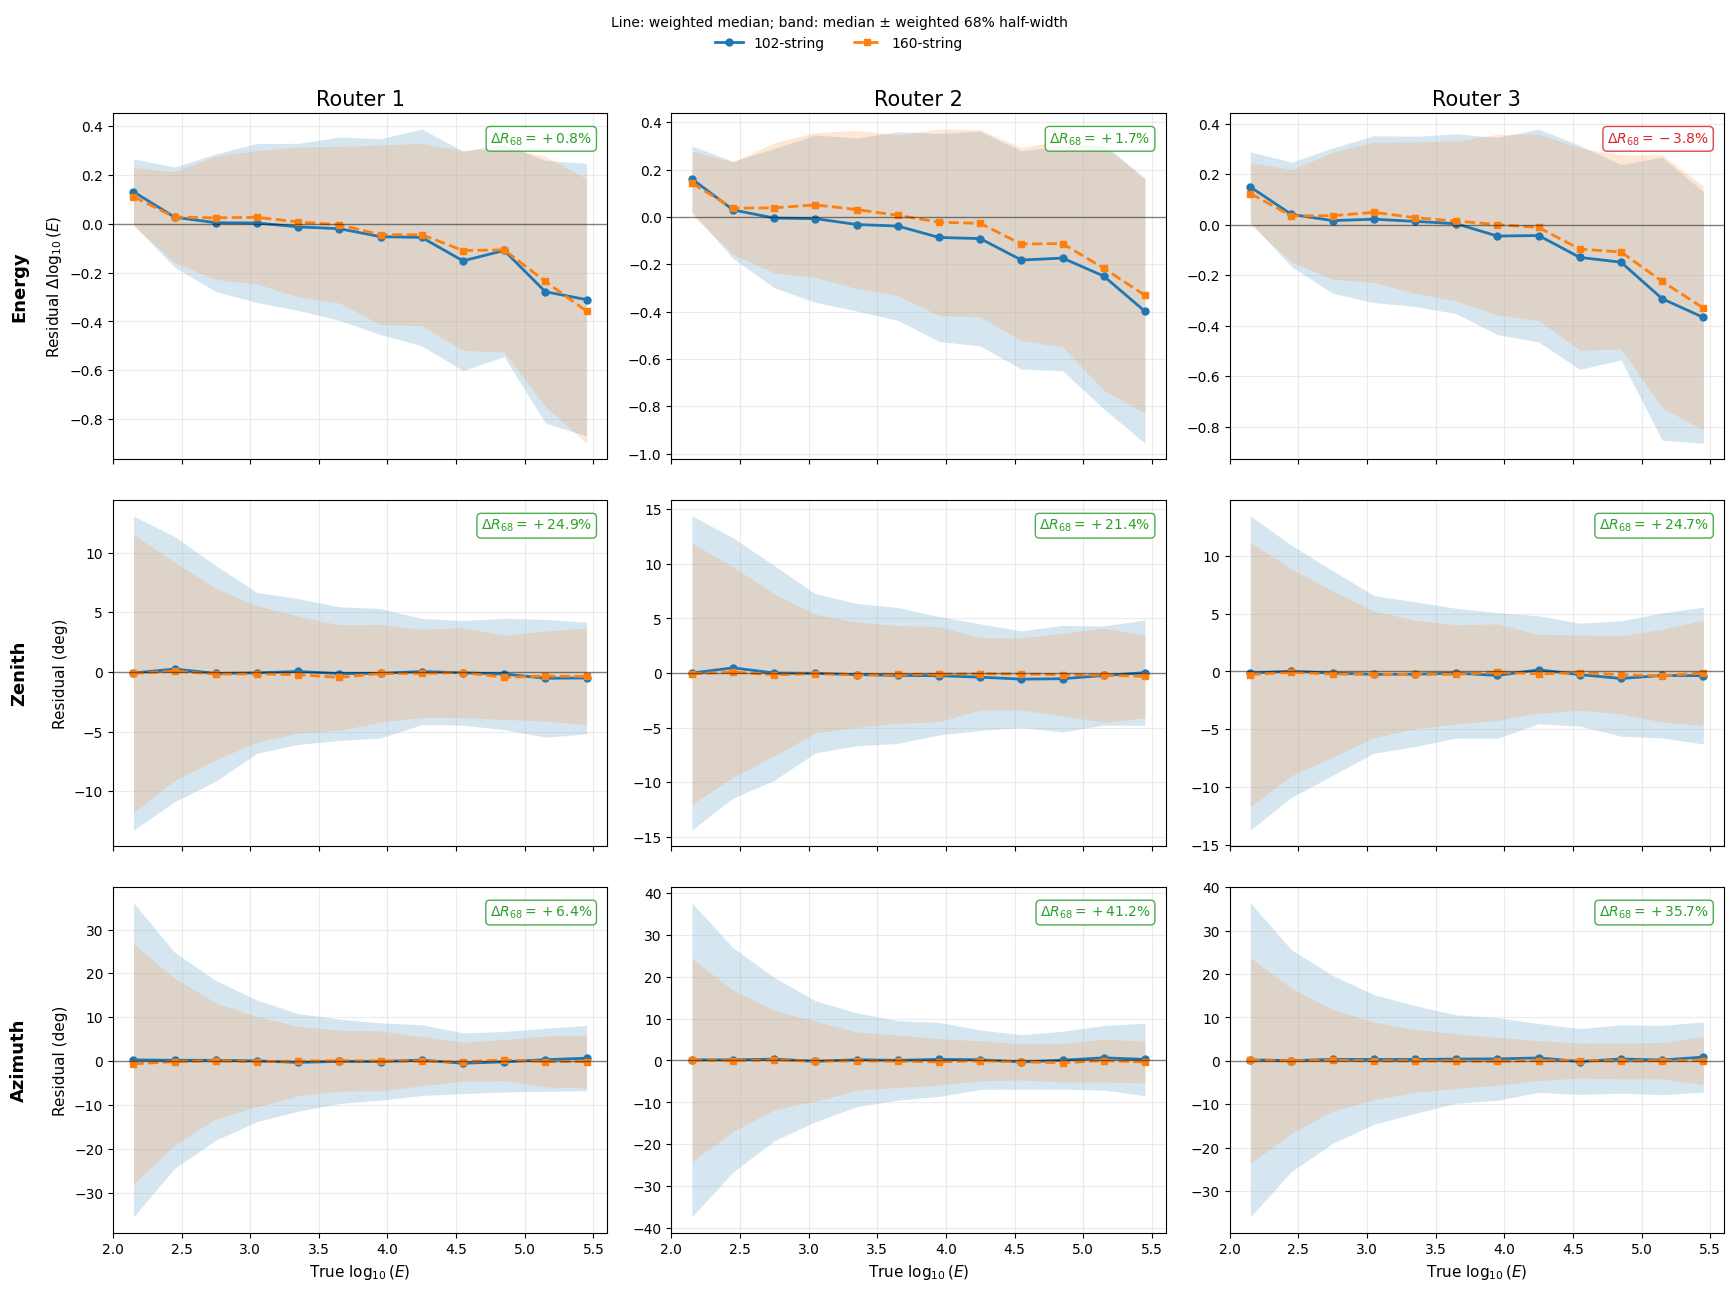

In [4]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def weighted_quantile(values, quantiles, weights):
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.full(quantiles.shape, np.nan)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative_weight = (np.cumsum(weights) - 0.5 * weights) / weights.sum()
    return np.interp(quantiles, cumulative_weight, values)


def weighted_68_half_width(values, weights):
    q16, q84 = weighted_quantile(values, [0.16, 0.84], weights)
    return 0.5 * (q84 - q16)


def unweighted_quantile(values, quantiles):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.full(len(quantiles), np.nan)
    return np.quantile(values, quantiles)


def unweighted_68_half_width(values):
    q16, q84 = unweighted_quantile(values, [0.16, 0.84])
    return 0.5 * (q84 - q16)


unweighted_bin_edges = np.arange(2.0, 5.6 + 0.001, 0.3)
unweighted_bin_centers = 0.5 * (
    unweighted_bin_edges[:-1] + unweighted_bin_edges[1:]
)
unweighted_detector_styles = {
    "102": {"color": "tab:blue", "linestyle": "-", "marker": "o"},
    "160": {"color": "tab:orange", "linestyle": "--", "marker": "s"},
}
unweighted_resolution_rows = {
    "energy": r"Residual $\Delta \log_{10}(E)$",
    "zenith": "Residual (deg)",
    "azimuth": "Residual (deg)",
}

fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharex=True, squeeze=False)
true_log_energy = master_df["true_log10_energy"]
event_weights = master_df["final_weight"]

for row, (variable, ylabel) in enumerate(unweighted_resolution_rows.items()):
    for column, router_name in enumerate(router_directories):
        ax = axes[row, column]
        global_resolutions = {}
        for detector, style in unweighted_detector_styles.items():
            prefix = f"{detector}_{router_name}_"
            if variable == "energy":
                residual = (
                    master_df[f"{prefix}pred_log10_energy"] - true_log_energy
                )
            else:
                residual = master_df[f"{prefix}residual_{variable}_degree"]
            global_resolutions[detector] = weighted_68_half_width(
                residual, event_weights
            )

            medians = []
            half_widths = []
            for low, high in zip(
                unweighted_bin_edges[:-1], unweighted_bin_edges[1:]
            ):
                in_bin = true_log_energy.between(low, high, inclusive="left")
                q16, q50, q84 = weighted_quantile(
                    residual[in_bin], [0.16, 0.50, 0.84], event_weights[in_bin]
                )
                medians.append(q50)
                half_widths.append(0.5 * (q84 - q16))

            medians = np.asarray(medians)
            half_widths = np.asarray(half_widths)
            ax.plot(
                unweighted_bin_centers,
                medians,
                linewidth=2,
                markersize=5,
                label=f"{detector}-string",
                **style,
            )
            ax.fill_between(
                unweighted_bin_centers,
                medians - half_widths,
                medians + half_widths,
                color=style["color"],
                alpha=0.18,
                linewidth=0,
            )

        resolution_improvement = 100.0 * (
            global_resolutions["102"] - global_resolutions["160"]
        ) / global_resolutions["102"]
        annotation_color = (
            "tab:green" if resolution_improvement > 0
            else "tab:red" if resolution_improvement < 0
            else "0.35"
        )
        ax.text(
            0.97,
            0.95,
            rf"$\Delta R_{{68}} = {resolution_improvement:+.1f}\%$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            fontweight="bold",
            color=annotation_color,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": annotation_color,
                "alpha": 0.85,
            },
        )

        if row == 0:
            ax.set_title(router_name.replace("router", "Router "), fontsize=15)
        if column == 0:
            ax.set_ylabel(ylabel, fontsize=11)
            ax.annotate(
                variable.title(),
                xy=(-0.19, 0.5),
                xycoords="axes fraction",
                rotation=90,
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
            )
        if row == 2:
            ax.set_xlabel(r"True $\log_{10}(E)$", fontsize=11)
        ax.axhline(0, color="black", linewidth=1, alpha=0.45)
        ax.set_xlim(unweighted_bin_edges[0], unweighted_bin_edges[-1])
        ax.grid(True, alpha=0.25)

legend_handles = [
    Line2D(
        [0], [0], linewidth=2, markersize=5,
        label=f"{detector}-string", **style,
    )
    for detector, style in unweighted_detector_styles.items()
]
fig.legend(
    handles=legend_handles,
    title="Line: weighted median; band: median ± weighted 68% half-width",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=2,
    frameon=False,
)
fig.tight_layout(rect=(0.04, 0, 1, 0.94), h_pad=2.0, w_pad=1.5)
plt.show()

### Weighted resolution by flavor-interaction channel

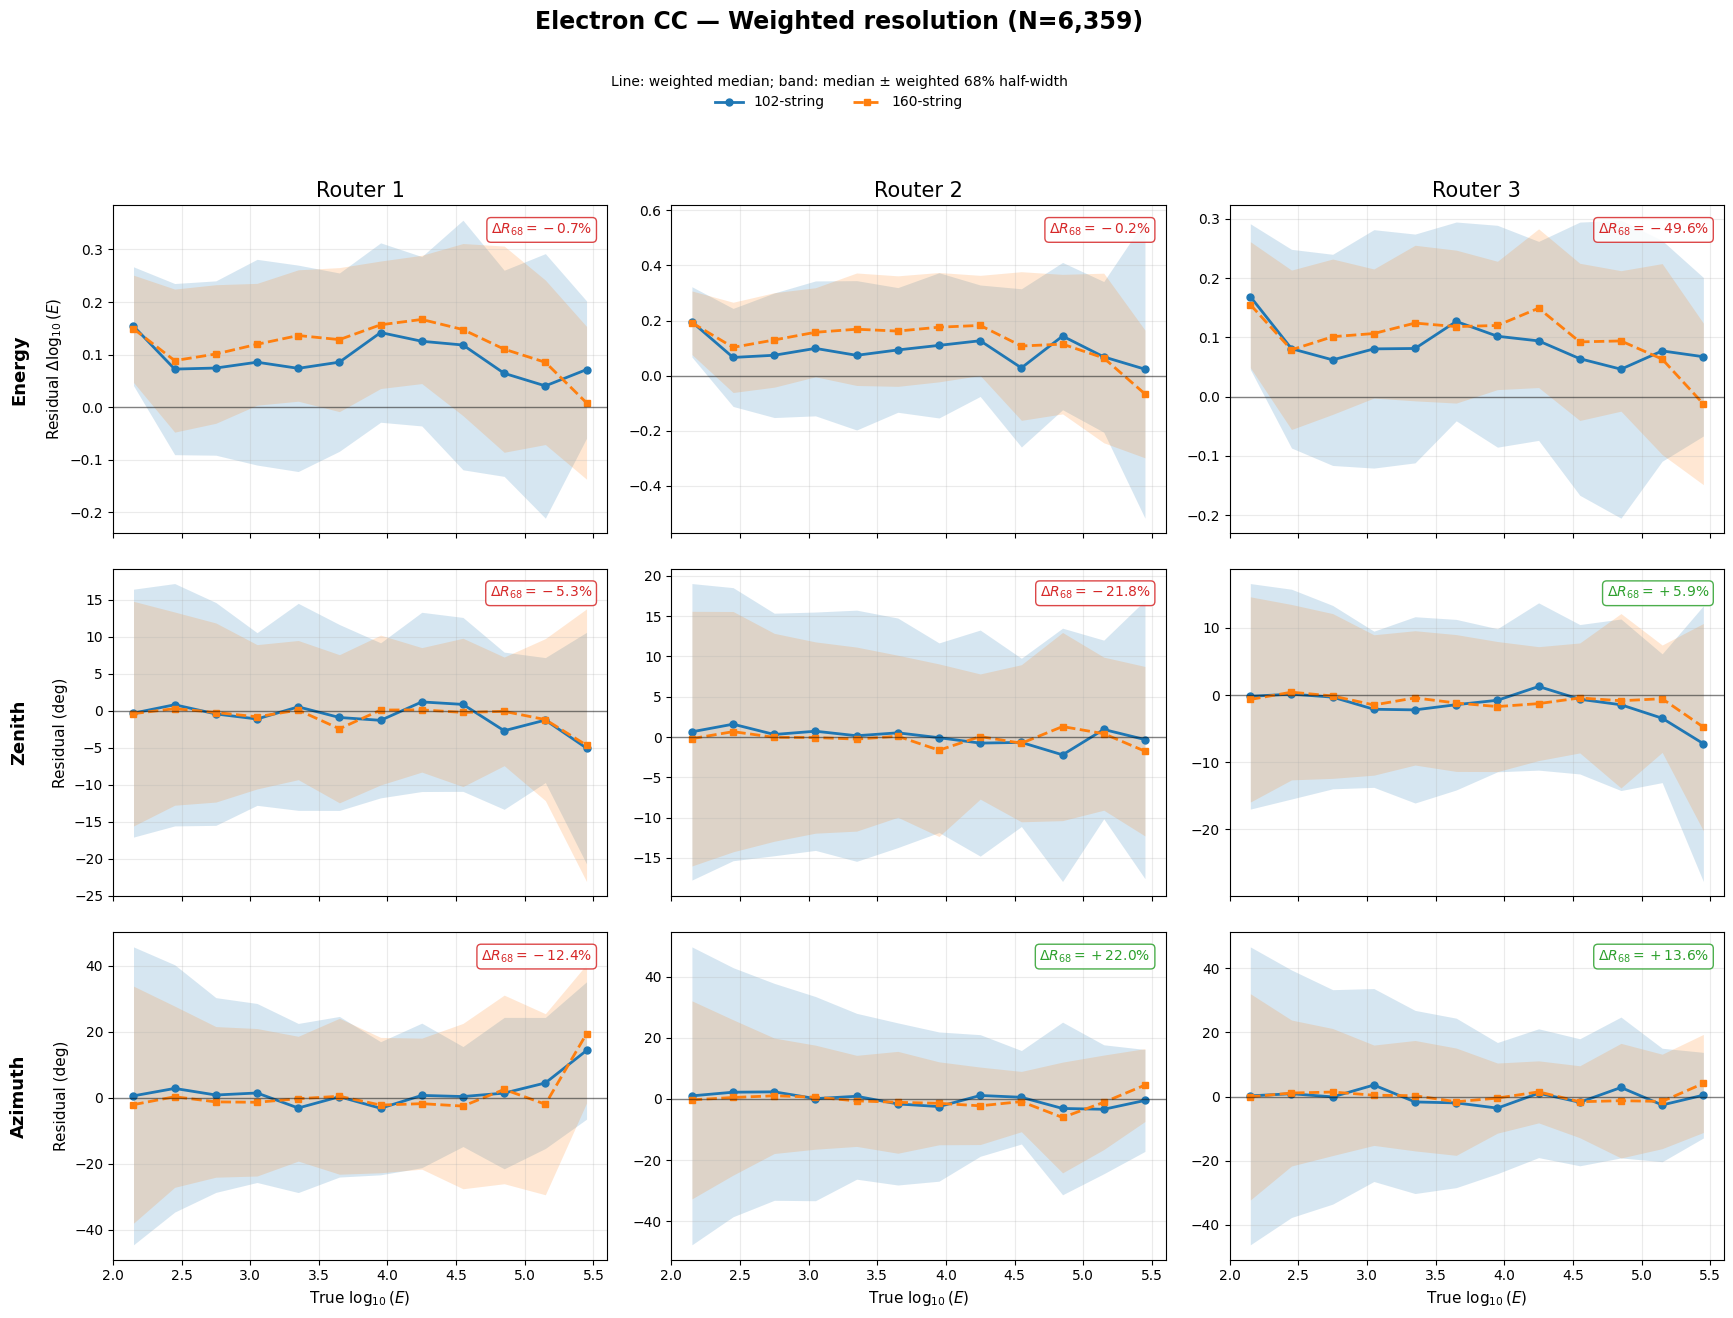

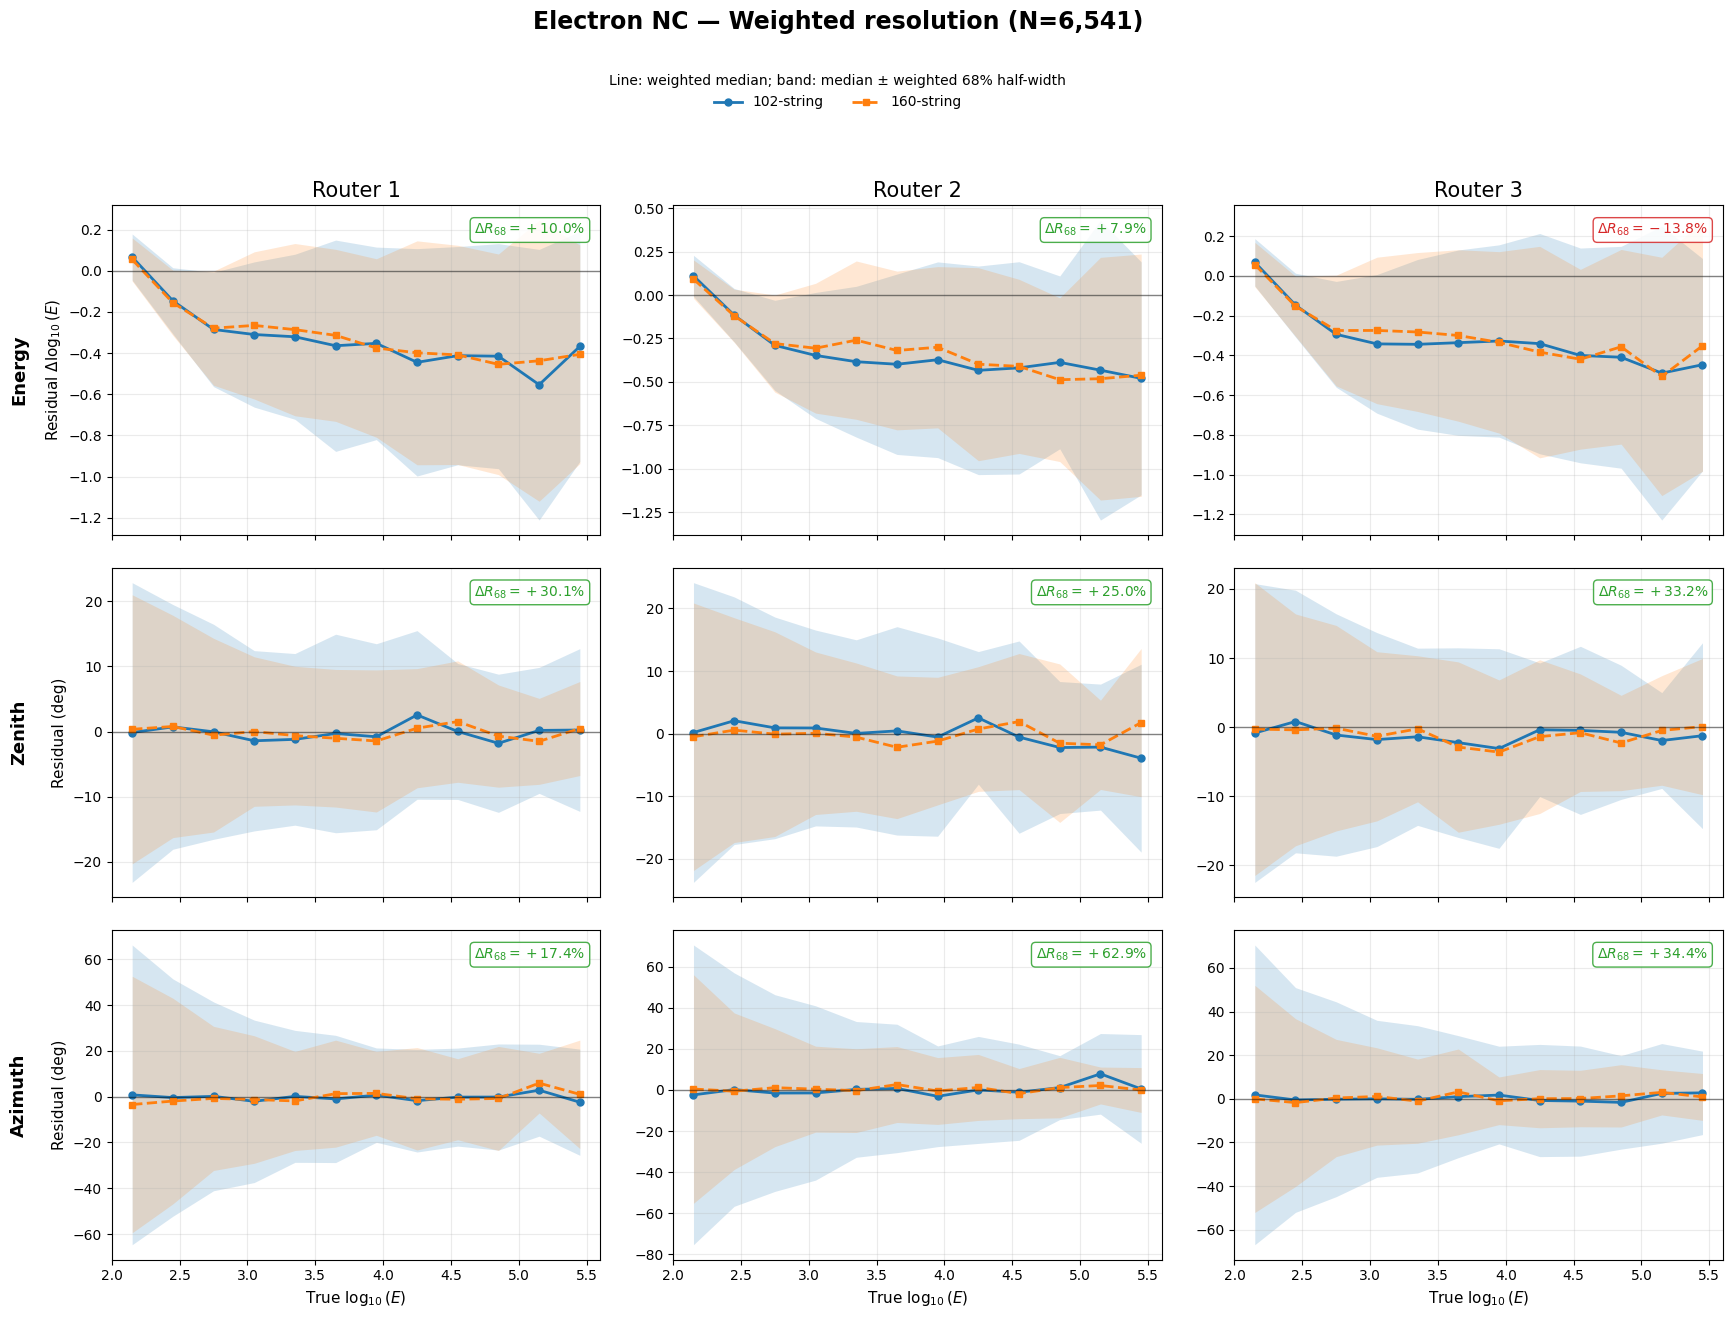

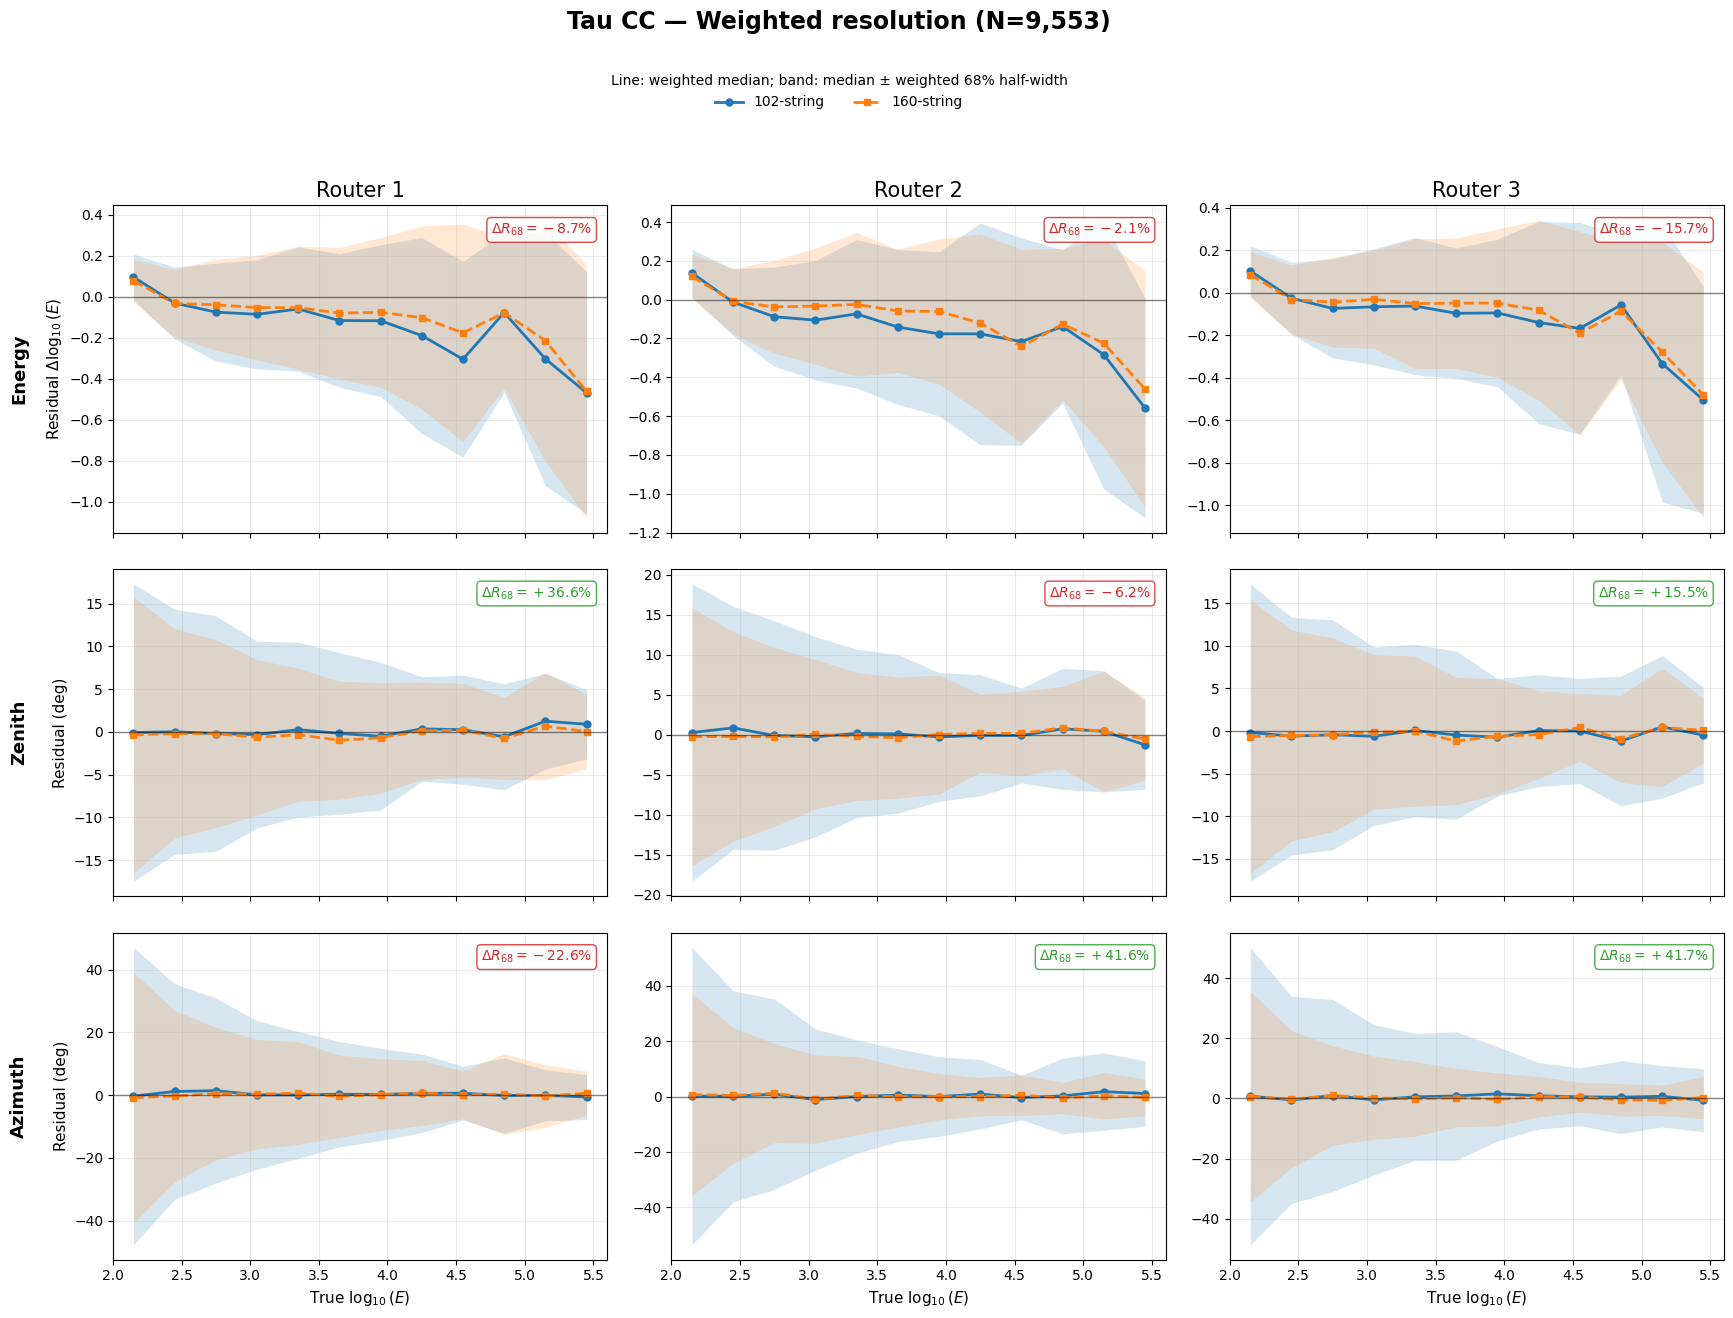

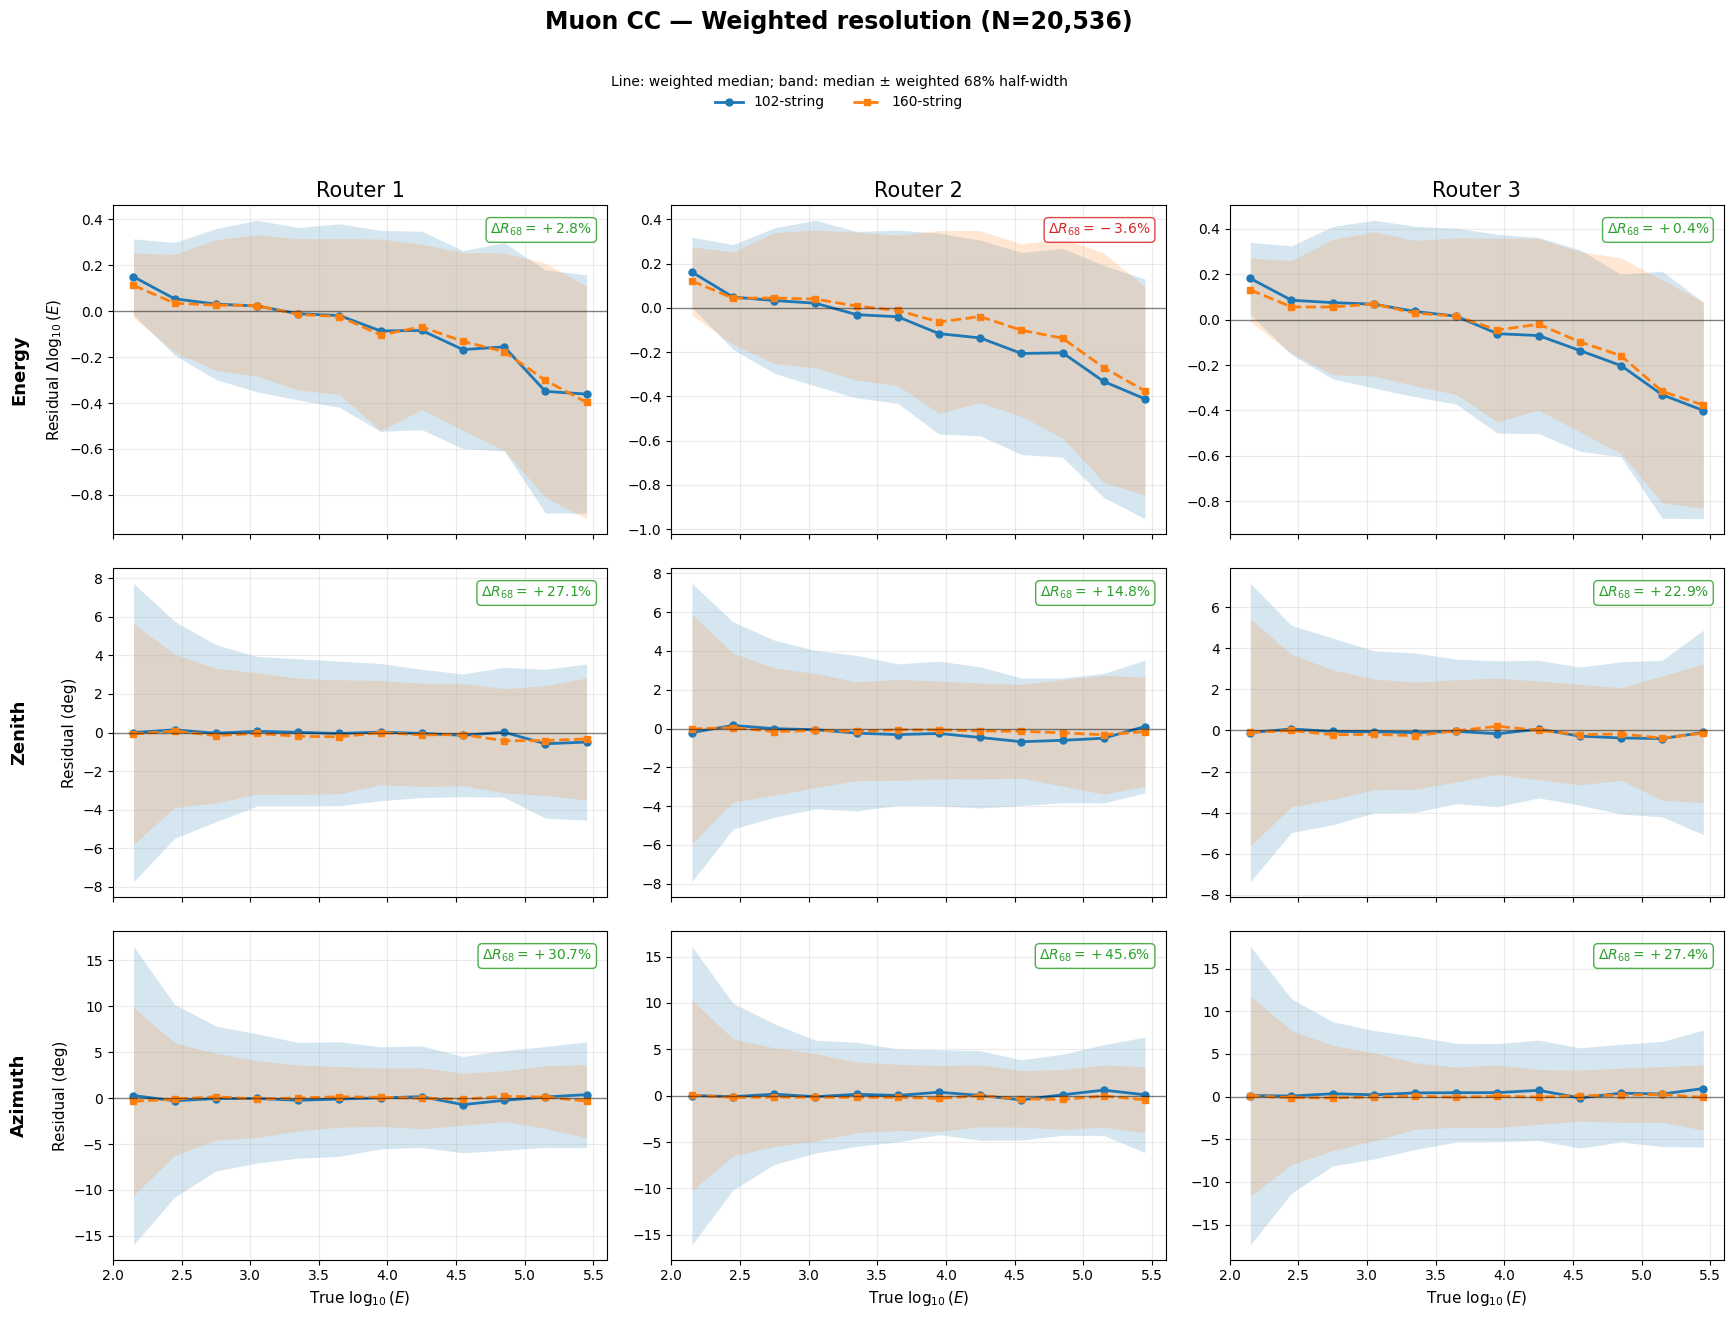

In [5]:
category_selections = [
    (
        "Electron CC",
        (master_df["pid"].abs() == 12) & (master_df["is_CC"] == 1),
    ),
    (
        "Electron NC",
        (master_df["pid"].abs() == 12) & (master_df["is_CC"] == 0),
    ),
    (
        "Tau CC",
        (master_df["pid"].abs() == 16) & (master_df["is_CC"] == 1),
    ),
    (
        "Muon CC",
        (master_df["pid"].abs() == 14) & (master_df["is_CC"] == 1),
    ),
]


def plot_resolution_for_category(category_label, category_mask, use_event_weights):
    plot_mode = "Weighted" if use_event_weights else "Unweighted"
    styles = {
        "102": {"color": "tab:blue", "linestyle": "-", "marker": "o"},
        "160": {"color": "tab:orange", "linestyle": "--", "marker": "s"},
    }
    row_config = {
        "energy": r"Residual $\Delta \log_{10}(E)$",
        "zenith": "Residual (deg)",
        "azimuth": "Residual (deg)",
    }
    local_bin_edges = np.arange(2.0, 5.6 + 0.001, 0.3)
    local_bin_centers = 0.5 * (local_bin_edges[:-1] + local_bin_edges[1:])
    true_log_energy = master_df["true_log10_energy"]
    event_weights = master_df["final_weight"]
    fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharex=True, squeeze=False)

    for row, (variable, ylabel) in enumerate(row_config.items()):
        for column, router_name in enumerate(router_directories):
            ax = axes[row, column]
            global_resolutions = {}
            for detector, style in styles.items():
                prefix = f"{detector}_{router_name}_"
                if variable == "energy":
                    residual = (
                        master_df[f"{prefix}pred_log10_energy"] - true_log_energy
                    )
                else:
                    residual = master_df[f"{prefix}residual_{variable}_degree"]

                if use_event_weights:
                    global_resolutions[detector] = weighted_68_half_width(
                        residual[category_mask], event_weights[category_mask]
                    )
                else:
                    global_resolutions[detector] = unweighted_68_half_width(
                        residual[category_mask]
                    )

                medians = []
                half_widths = []
                for low, high in zip(local_bin_edges[:-1], local_bin_edges[1:]):
                    in_bin = category_mask & true_log_energy.between(
                        low, high, inclusive="left"
                    )
                    if use_event_weights:
                        q16, q50, q84 = weighted_quantile(
                            residual[in_bin],
                            [0.16, 0.50, 0.84],
                            event_weights[in_bin],
                        )
                    else:
                        q16, q50, q84 = unweighted_quantile(
                            residual[in_bin], [0.16, 0.50, 0.84]
                        )
                    medians.append(q50)
                    half_widths.append(0.5 * (q84 - q16))

                medians = np.asarray(medians)
                half_widths = np.asarray(half_widths)
                ax.plot(
                    local_bin_centers,
                    medians,
                    linewidth=2,
                    markersize=5,
                    label=f"{detector}-string",
                    **style,
                )
                ax.fill_between(
                    local_bin_centers,
                    medians - half_widths,
                    medians + half_widths,
                    color=style["color"],
                    alpha=0.18,
                    linewidth=0,
                )

            resolution_improvement = 100.0 * (
                global_resolutions["102"] - global_resolutions["160"]
            ) / global_resolutions["102"]
            annotation_color = (
                "tab:green" if resolution_improvement > 0
                else "tab:red" if resolution_improvement < 0
                else "0.35"
            )
            ax.text(
                0.97,
                0.95,
                rf"$\Delta R_{{68}} = {resolution_improvement:+.1f}\%$",
                transform=ax.transAxes,
                ha="right",
                va="top",
                fontsize=10,
                fontweight="bold",
                color=annotation_color,
                bbox={
                    "boxstyle": "round,pad=0.3",
                    "facecolor": "white",
                    "edgecolor": annotation_color,
                    "alpha": 0.85,
                },
            )

            if row == 0:
                ax.set_title(router_name.replace("router", "Router "), fontsize=15)
            if column == 0:
                ax.set_ylabel(ylabel, fontsize=11)
                ax.annotate(
                    variable.title(),
                    xy=(-0.19, 0.5),
                    xycoords="axes fraction",
                    rotation=90,
                    ha="center",
                    va="center",
                    fontsize=13,
                    fontweight="bold",
                )
            if row == 2:
                ax.set_xlabel(r"True $\log_{10}(E)$", fontsize=11)
            ax.axhline(0, color="black", linewidth=1, alpha=0.45)
            ax.set_xlim(local_bin_edges[0], local_bin_edges[-1])
            ax.grid(True, alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0], linewidth=2, markersize=5,
            label=f"{detector}-string", **style,
        )
        for detector, style in styles.items()
    ]
    fig.suptitle(
        f"{category_label} — {plot_mode} resolution (N={int(category_mask.sum()):,})",
        fontsize=17,
        fontweight="bold",
        y=1.01,
    )
    fig.legend(
        handles=legend_handles,
        title=(
            f"Line: {plot_mode.lower()} median; "
            f"band: median ± {plot_mode.lower()} 68% half-width"
        ),
        loc="upper center",
        bbox_to_anchor=(0.5, 0.97),
        ncol=2,
        frameon=False,
    )
    fig.tight_layout(rect=(0.04, 0, 1, 0.92), h_pad=2.0, w_pad=1.5)
    plt.show()


for category_label, category_mask in category_selections:
    plot_resolution_for_category(
        category_label, category_mask, use_event_weights=True
    )

## Unweighted resolution: 102-string vs 160-string

Each line shows the unweighted median residual, and each shaded region shows the median $\pm$ unweighted 68% half-width. The number in each panel summarizes the unweighted resolution improvement of the 160-string configuration relative to the 102-string configuration over all common events:

$$
\Delta R_{68} (\%) = 100 \times \frac{R_{68}^{102} - R_{68}^{160}}{R_{68}^{102}}
$$

Here, $R_{68}$ is the global unweighted 68% half-width for that router and reconstruction variable. A positive value means that the 160-string configuration has a narrower (better) resolution; a negative value means that its resolution is wider (worse).

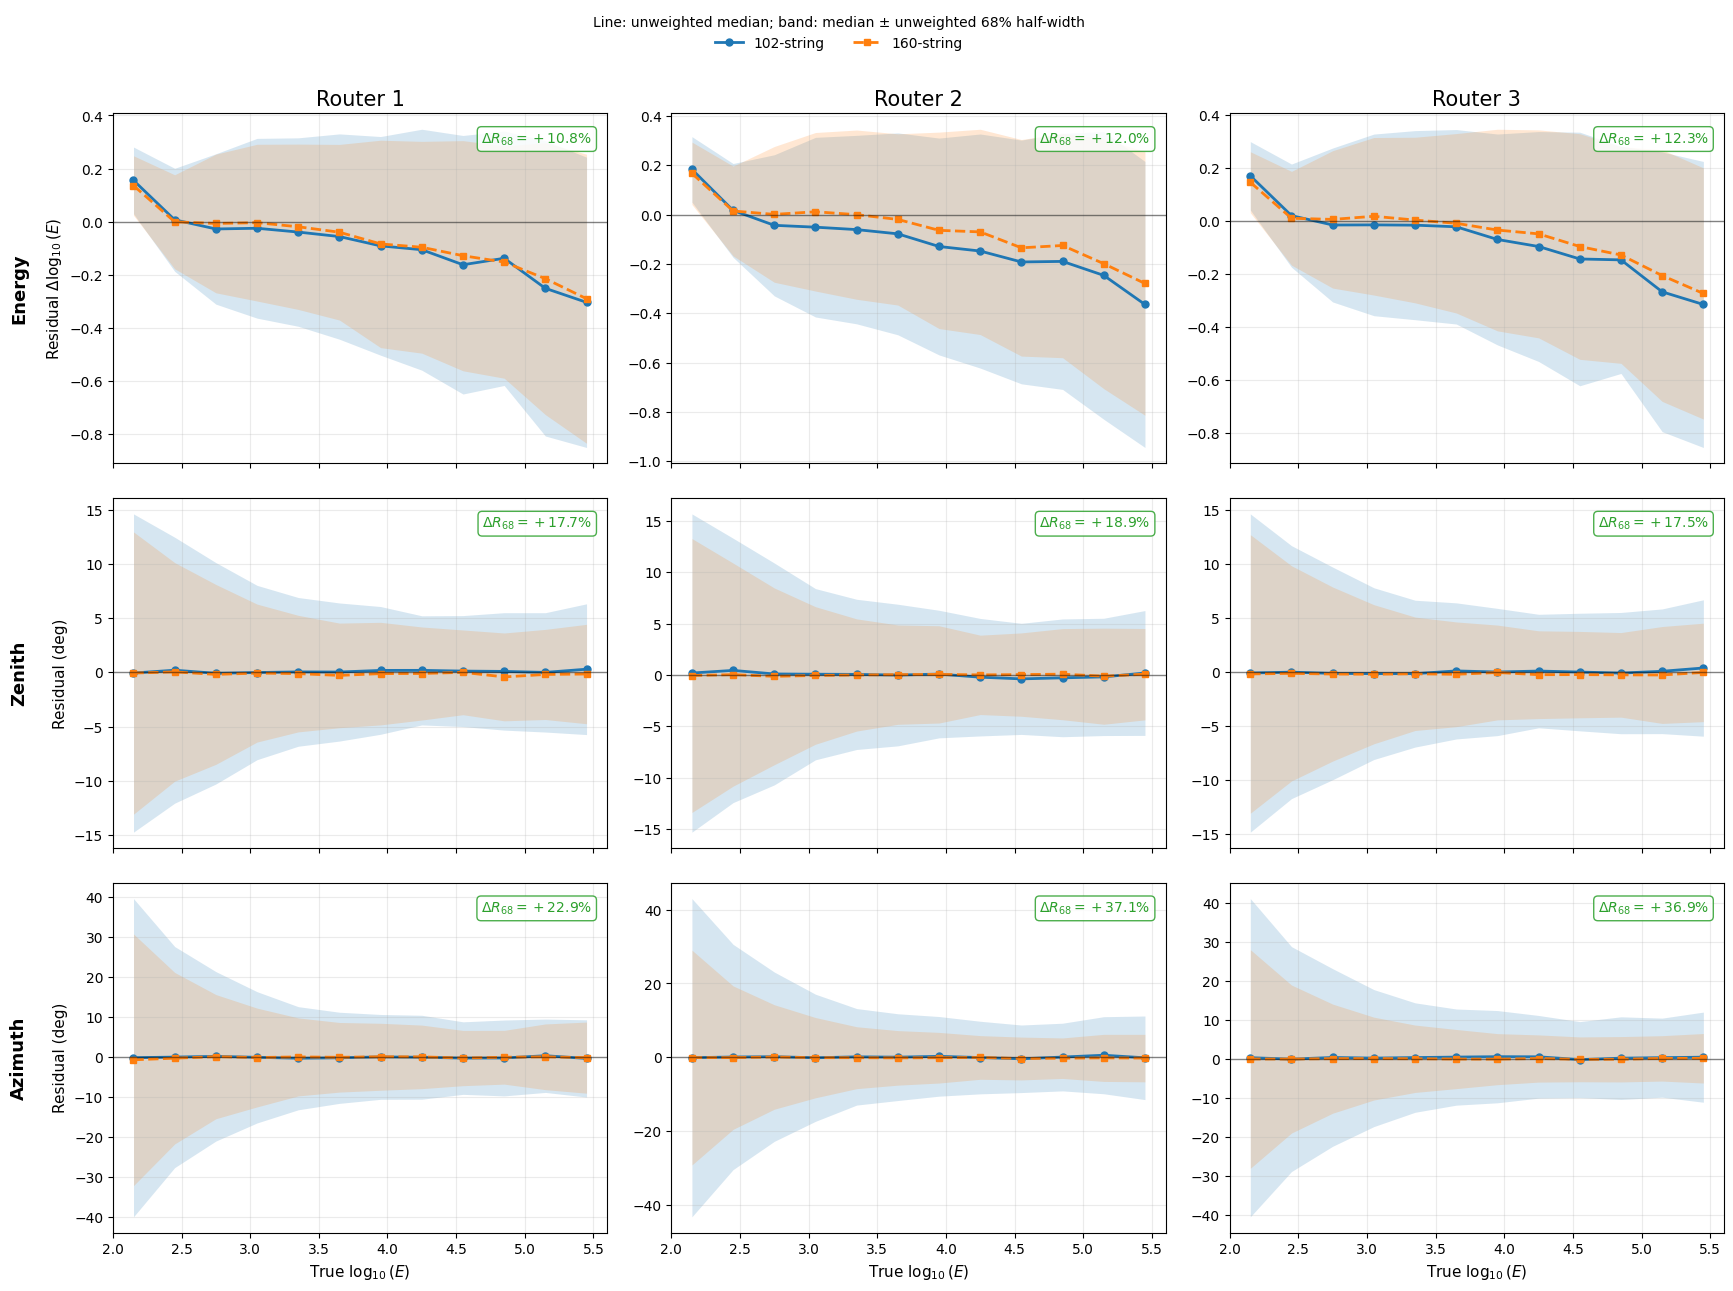

In [6]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def weighted_quantile(values, quantiles, weights):
    values = np.asarray(values, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    values = values[valid]
    weights = weights[valid]
    if values.size == 0:
        return np.full(quantiles.shape, np.nan)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative_weight = (np.cumsum(weights) - 0.5 * weights) / weights.sum()
    return np.interp(quantiles, cumulative_weight, values)


def weighted_68_half_width(values, weights):
    q16, q84 = weighted_quantile(values, [0.16, 0.84], weights)
    return 0.5 * (q84 - q16)


bin_edges = np.arange(2.0, 5.6 + 0.001, 0.3)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
detector_styles = {
    "102": {"color": "tab:blue", "linestyle": "-", "marker": "o"},
    "160": {"color": "tab:orange", "linestyle": "--", "marker": "s"},
}
resolution_rows = {
    "energy": r"Residual $\Delta \log_{10}(E)$",
    "zenith": "Residual (deg)",
    "azimuth": "Residual (deg)",
}

fig, axes = plt.subplots(3, 3, figsize=(18, 13), sharex=True, squeeze=False)
true_log_energy = master_df["true_log10_energy"]
event_weights = master_df["final_weight"]

for row, (variable, ylabel) in enumerate(resolution_rows.items()):
    for column, router_name in enumerate(router_directories):
        ax = axes[row, column]
        global_resolutions = {}
        for detector, style in detector_styles.items():
            prefix = f"{detector}_{router_name}_"
            if variable == "energy":
                residual = (
                    master_df[f"{prefix}pred_log10_energy"] - true_log_energy
                )
            else:
                residual = master_df[f"{prefix}residual_{variable}_degree"]
            global_resolutions[detector] = unweighted_68_half_width(residual)

            medians = []
            half_widths = []
            for low, high in zip(bin_edges[:-1], bin_edges[1:]):
                in_bin = true_log_energy.between(low, high, inclusive="left")
                q16, q50, q84 = unweighted_quantile(
                    residual[in_bin], [0.16, 0.50, 0.84]
                )
                medians.append(q50)
                half_widths.append(0.5 * (q84 - q16))

            medians = np.asarray(medians)
            half_widths = np.asarray(half_widths)
            ax.plot(
                bin_centers,
                medians,
                linewidth=2,
                markersize=5,
                label=f"{detector}-string",
                **style,
            )
            ax.fill_between(
                bin_centers,
                medians - half_widths,
                medians + half_widths,
                color=style["color"],
                alpha=0.18,
                linewidth=0,
            )

        resolution_improvement = 100.0 * (
            global_resolutions["102"] - global_resolutions["160"]
        ) / global_resolutions["102"]
        annotation_color = (
            "tab:green" if resolution_improvement > 0
            else "tab:red" if resolution_improvement < 0
            else "0.35"
        )
        ax.text(
            0.97,
            0.95,
            rf"$\Delta R_{{68}} = {resolution_improvement:+.1f}\%$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            fontweight="bold",
            color=annotation_color,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": annotation_color,
                "alpha": 0.85,
            },
        )

        if row == 0:
            ax.set_title(router_name.replace("router", "Router "), fontsize=15)
        if column == 0:
            ax.set_ylabel(ylabel, fontsize=11)
            ax.annotate(
                variable.title(),
                xy=(-0.19, 0.5),
                xycoords="axes fraction",
                rotation=90,
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
            )
        if row == 2:
            ax.set_xlabel(r"True $\log_{10}(E)$", fontsize=11)
        ax.axhline(0, color="black", linewidth=1, alpha=0.45)
        ax.set_xlim(bin_edges[0], bin_edges[-1])
        ax.grid(True, alpha=0.25)

legend_handles = [
    Line2D([0], [0], linewidth=2, markersize=5, label=f"{detector}-string", **style)
    for detector, style in detector_styles.items()
]
fig.legend(
    handles=legend_handles,
    title="Line: unweighted median; band: median ± unweighted 68% half-width",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=2,
    frameon=False,
)
fig.tight_layout(rect=(0.04, 0, 1, 0.94), h_pad=2.0, w_pad=1.5)
plt.show()

### Unweighted resolution by flavor-interaction channel

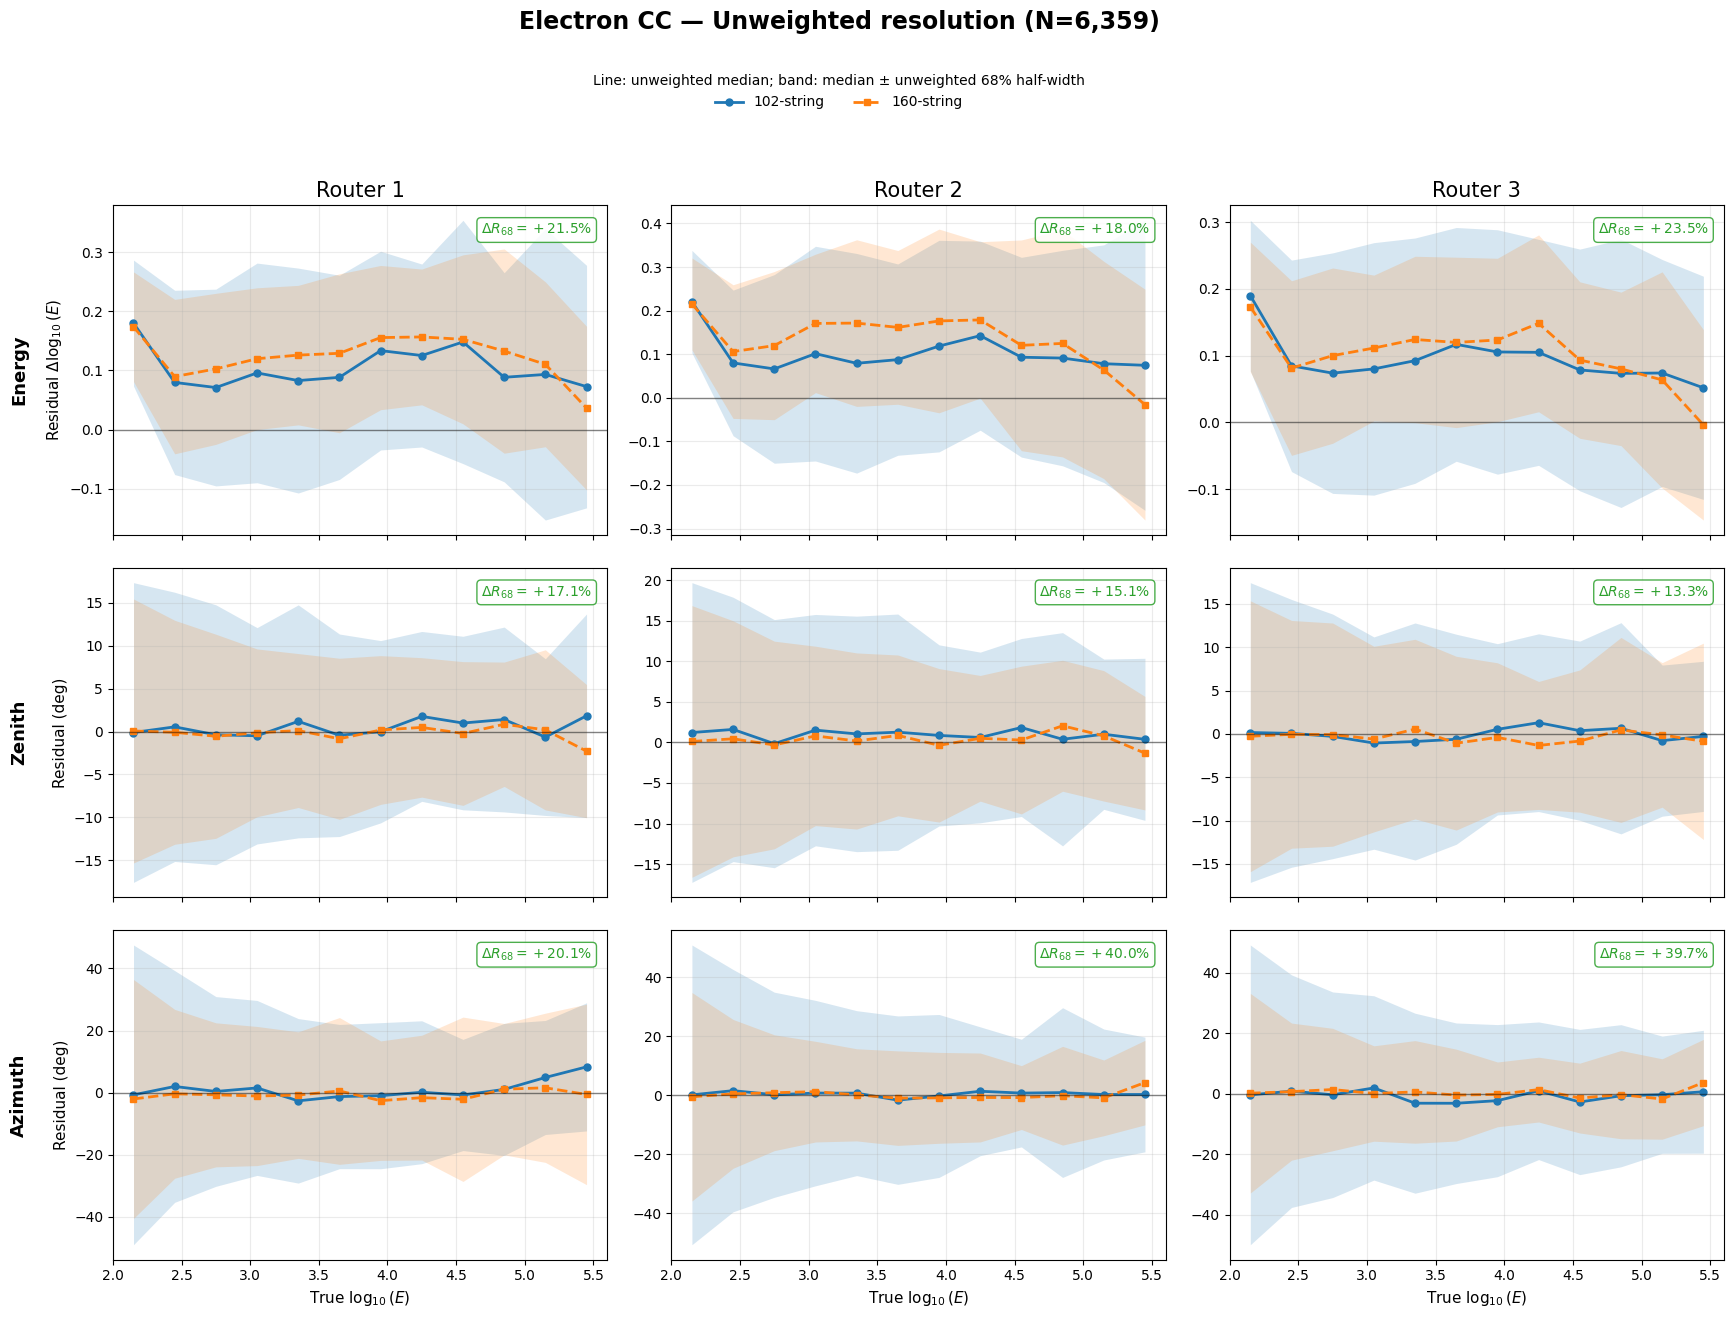

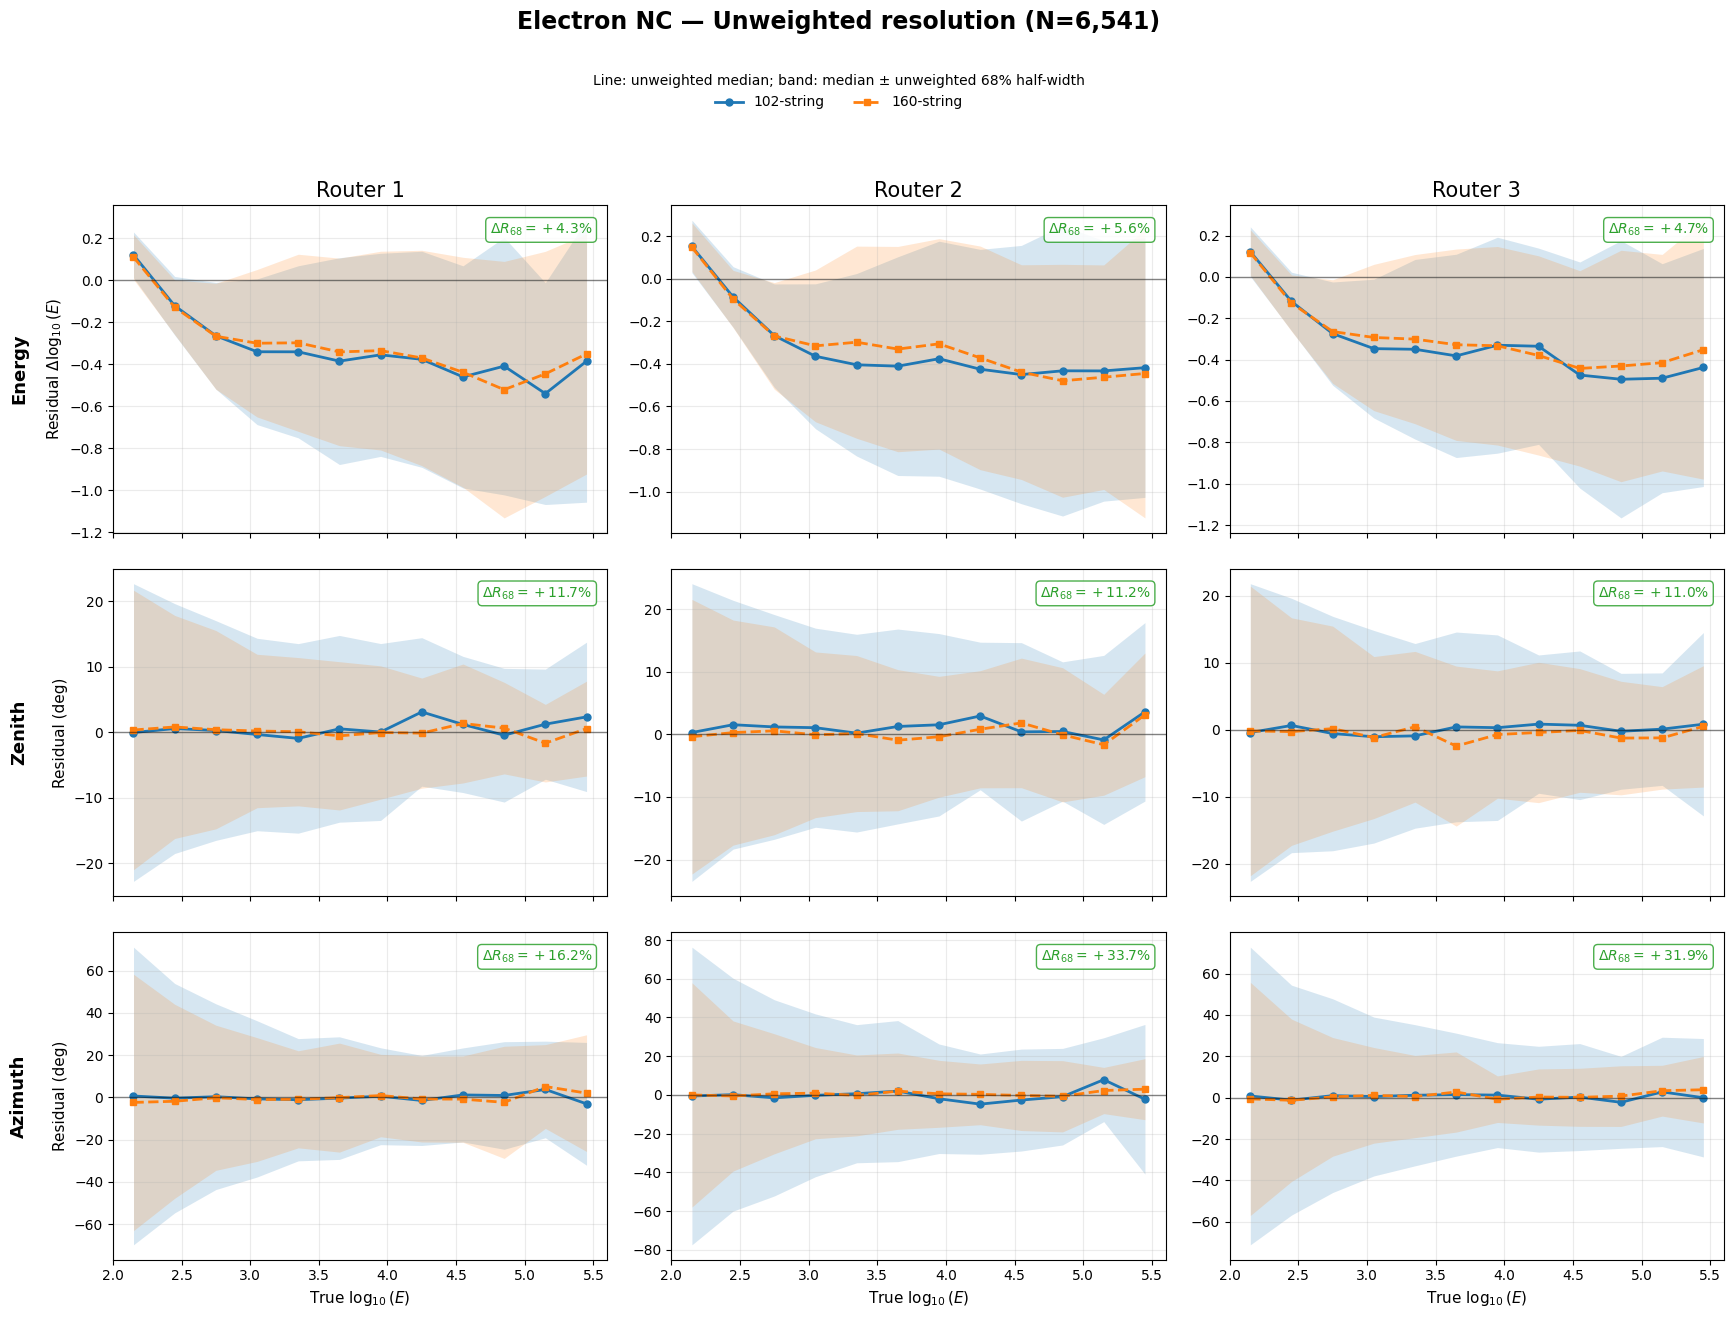

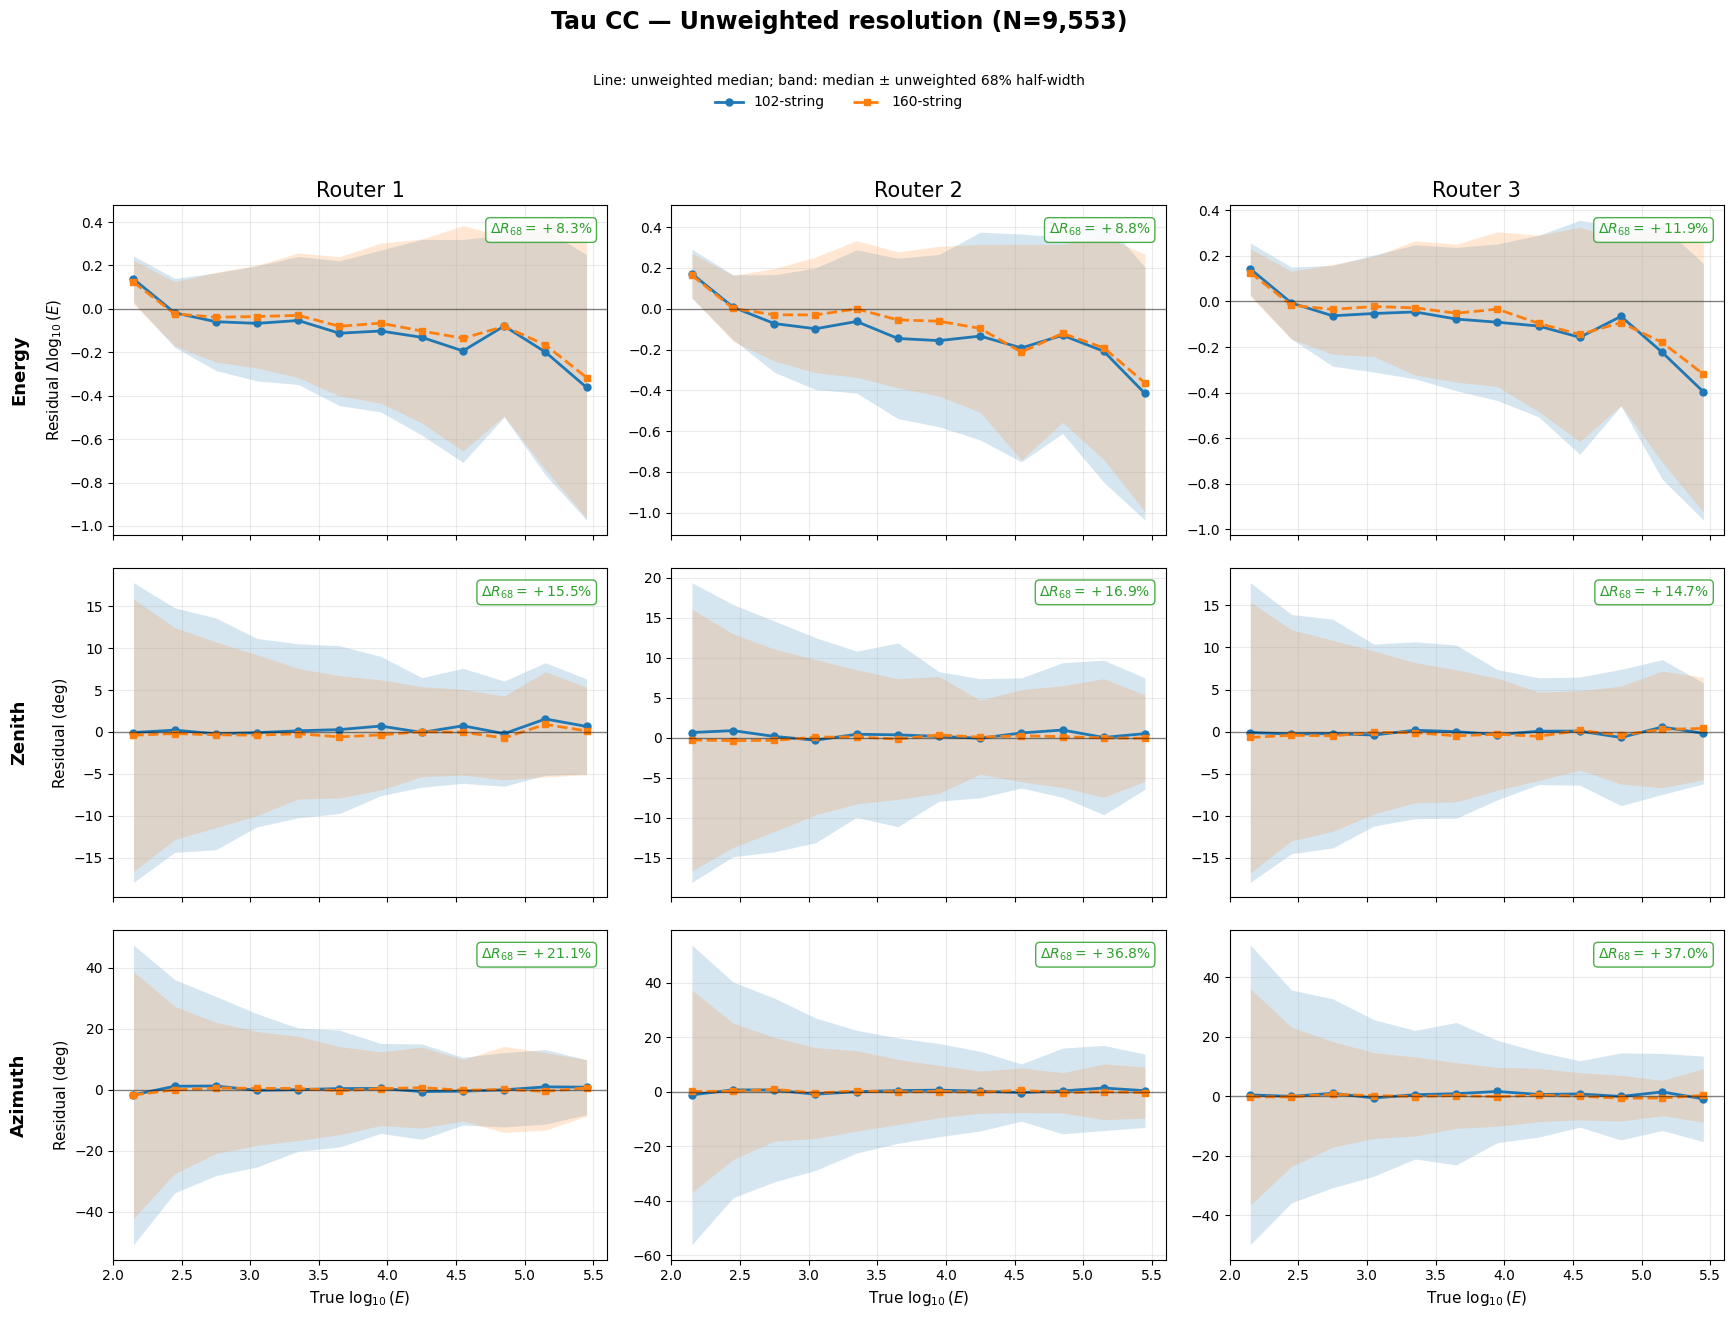

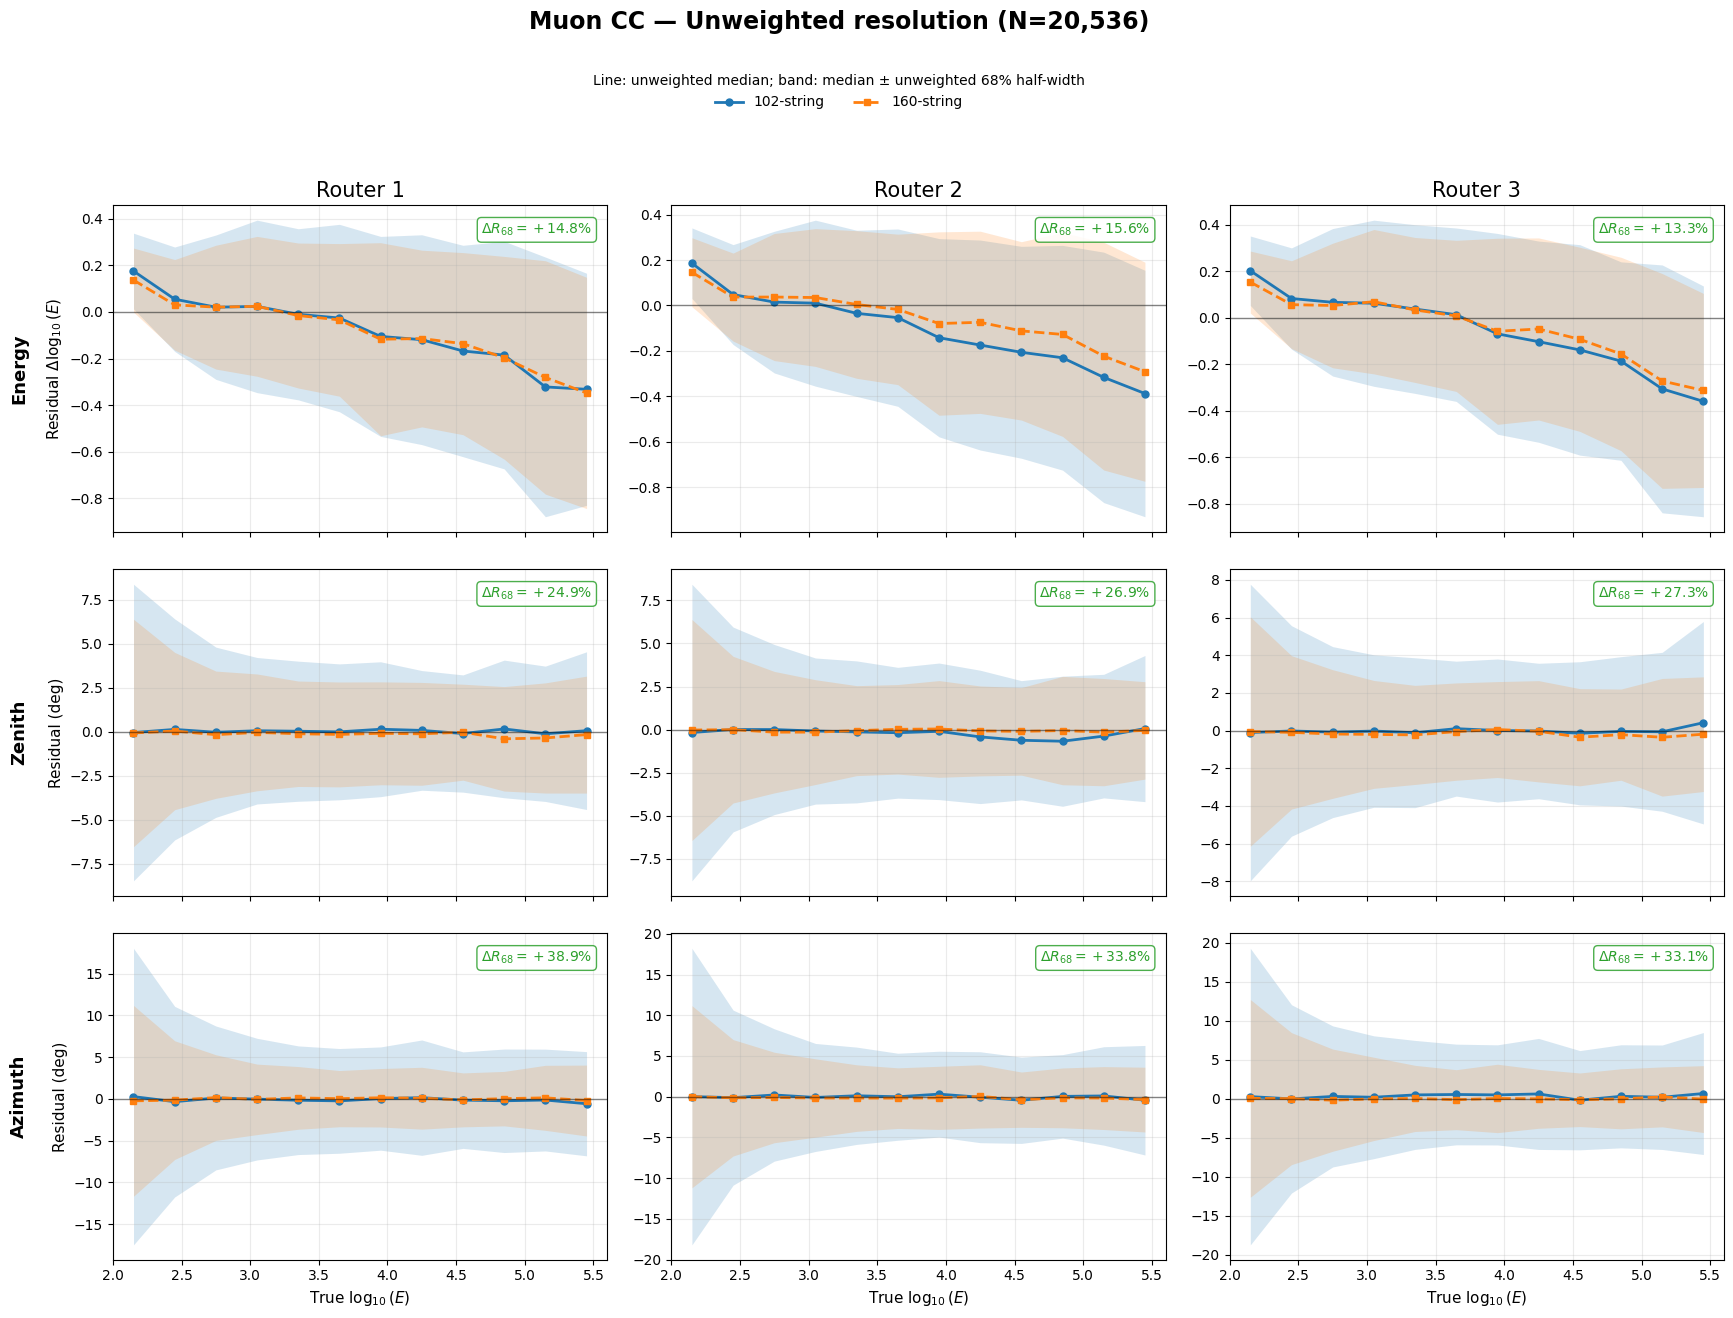

In [7]:
for category_label, category_mask in category_selections:
    plot_resolution_for_category(
        category_label, category_mask, use_event_weights=False
    )